## Task 1 — DBSCAN on Mall Customers

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

np.random.seed(42)

mall = pd.DataFrame({
    "Annual Income (k)": np.concatenate([
        np.random.normal(40, 7, 60),
        np.random.normal(80, 8, 70),
        np.random.normal(125, 9, 60),
        [15, 180, 190, 200]
    ]),
    
    "Spending Score (1-100)": np.concatenate([
        np.random.normal(30, 8, 60),
        np.random.normal(55, 9, 70),
        np.random.normal(75, 8, 60),
        [5, 5, 98, 2]
    ])
})

features = mall[["Annual Income (k)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

dbscan = DBSCAN(eps=0.28, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

mall["Cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("DBSCAN Results")
print("=" * 35)
print(f"Number of clusters found : {n_clusters}")
print(f"Number of noise points   : {n_noise}")

DBSCAN Results
Number of clusters found : 3
Number of noise points   : 9


## Task 2 — Visualize DBSCAN Results

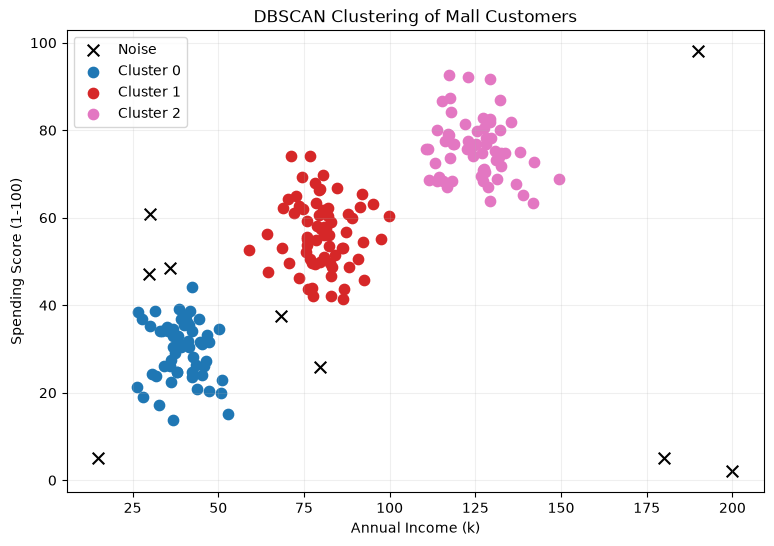

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(unique_labels))))
color_index = 0

for cluster in unique_labels:
    mask = labels == cluster

    if cluster == -1:
        plt.scatter(
            features.loc[mask, "Annual Income (k)"],
            features.loc[mask, "Spending Score (1-100)"],
            c="black",
            marker="x",
            s=70,
            label="Noise"
        )
    else:
        plt.scatter(
            features.loc[mask, "Annual Income (k)"],
            features.loc[mask, "Spending Score (1-100)"],
            color=colors[color_index],
            s=55,
            label=f"Cluster {cluster}"
        )
        color_index += 1

plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering of Mall Customers")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Task 3 — Changing DBSCAN Parameters

In [4]:
parameter_sets = [
    (0.20, 5),
    (0.28, 5),
    (0.40, 5),
    (0.28, 8)
]

results = []

for eps, min_samples in parameter_sets:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    result = model.fit_predict(X_scaled)

    clusters = len(set(result)) - (1 if -1 in result else 0)
    noise = np.sum(result == -1)

    results.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": clusters,
        "noise_points": noise
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))



 eps  min_samples  clusters  noise_points
0.20            5         3            27
0.28            5         3             9
0.40            5         3             6
0.28            8         3            14


## Task 4 — DBSCAN vs K-Means

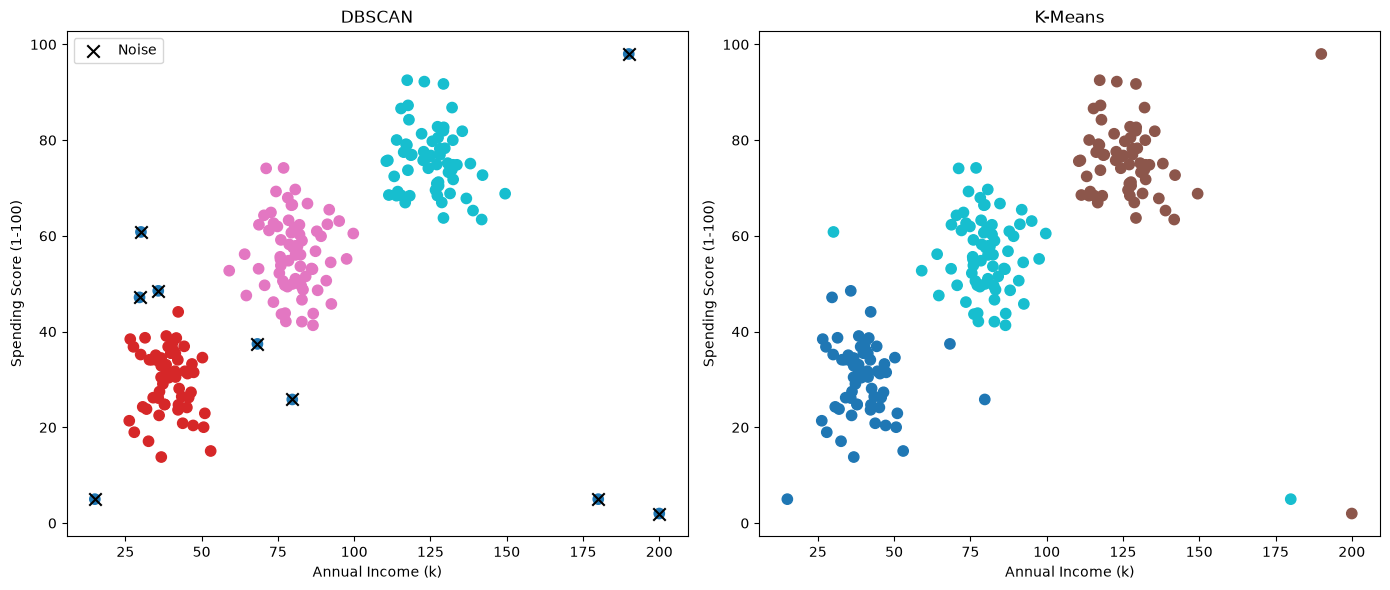

DBSCAN clusters used for K-Means: 3


In [7]:
from sklearn.cluster import KMeans

dbscan_for_comparison = DBSCAN(eps=0.28, min_samples=5)
dbscan_labels = dbscan_for_comparison.fit_predict(X_scaled)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

kmeans = KMeans(n_clusters=dbscan_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    features["Annual Income (k)"],
    features["Spending Score (1-100)"],
    c=dbscan_labels,
    cmap="tab10",
    s=55
)

noise_mask = dbscan_labels == -1

axes[0].scatter(
    features.loc[noise_mask, "Annual Income (k)"],
    features.loc[noise_mask, "Spending Score (1-100)"],
    c="black",
    marker="x",
    s=80,
    label="Noise"
)

axes[0].set_title("DBSCAN")
axes[0].set_xlabel("Annual Income (k)")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].legend()

axes[1].scatter(
    features["Annual Income (k)"],
    features["Spending Score (1-100)"],
    c=kmeans_labels,
    cmap="tab10",
    s=55
)

axes[1].set_title("K-Means")
axes[1].set_xlabel("Annual Income (k)")
axes[1].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

print(f"DBSCAN clusters used for K-Means: {dbscan_clusters}")


## Task 5 — DBSCAN on Non-Spherical Data

Make Moons DBSCAN Results
Number of clusters : 2
Number of noise points : 0

Noise point indices:
[]


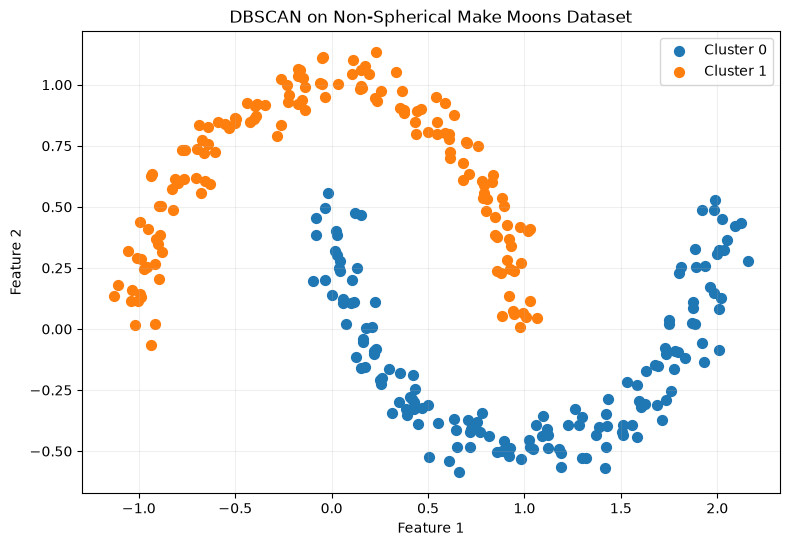

In [8]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.06,
    random_state=42
)

moon_model = DBSCAN(eps=0.18, min_samples=5)
moon_labels = moon_model.fit_predict(X_moons)

moon_clusters = len(set(moon_labels)) - (1 if -1 in moon_labels else 0)
moon_noise_indices = np.where(moon_labels == -1)[0]

print("Make Moons DBSCAN Results")
print("=" * 35)
print(f"Number of clusters : {moon_clusters}")
print(f"Number of noise points : {len(moon_noise_indices)}")
print()
print("Noise point indices:")
print(moon_noise_indices.tolist())

plt.figure(figsize=(9, 6))

for cluster in sorted(set(moon_labels)):
    mask = moon_labels == cluster

    if cluster == -1:
        plt.scatter(
            X_moons[mask, 0],
            X_moons[mask, 1],
            c="black",
            marker="x",
            s=70,
            label="Noise"
        )
    else:
        plt.scatter(
            X_moons[mask, 0],
            X_moons[mask, 1],
            s=50,
            label=f"Cluster {cluster}"
        )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN on Non-Spherical Make Moons Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()